In [21]:
"""
https://catboost.ai/docs/en/concepts/python-reference_catboostregressor_fit

To drop: numwrk, totwag, unempdur
Fillna: immigr (3.0), disabl (0.0), 
Filter nan rows: mart_d, yeduc
"""

'\nhttps://catboost.ai/docs/en/concepts/python-reference_catboostregressor_fit\n\nTo drop: numwrk, totwag, unempdur\nFillna: immigr (3.0), disabl (0.0), \nFilter nan rows: mart_d, yeduc\n'

In [22]:
import pandas as pd
import geopandas as gpd
import numpy as np
import rasterio
import catboost

from tqdm.auto import tqdm
from pathlib import Path

In [23]:
import os

REPO_ROOT = Path.cwd().parent
LOCAL_DATA_ROOT = Path(os.environ.get("EGYPT_DATA_ROOT", REPO_ROOT / "ERF_Data" / "Data" / "04_Data"))

_onedrive_home = Path("~").expanduser()
_onedrive_candidates = [
    _onedrive_home / "OneDrive - Stichting Deltares/Tiaravanni Hermawan's files",
    _onedrive_home / "OneDrive - Stichting Deltares/PhD",
]
_onedrive_root = next((p for p in _onedrive_candidates if (p / "Egypt").exists()), None)

if _onedrive_root is not None:
    src_dir = _onedrive_root / "Egypt/04_Data/2026_data/"
    excel_path = _onedrive_root / "Egypt_ERF_data/data_correlation.xlsx"
    RESULT_DIR = src_dir.parent / "Result"
    print(f"data source: OneDrive ({_onedrive_root})")
else:
    src_dir = LOCAL_DATA_ROOT
    excel_path = LOCAL_DATA_ROOT / "data_correlation.xlsx"
    RESULT_DIR = LOCAL_DATA_ROOT / "Result"
    print(f"data source: local (EGYPT_DATA_ROOT={LOCAL_DATA_ROOT})")

data source: local (EGYPT_DATA_ROOT=d:\KARISMA\POST GRADUATE\UT\Intership\Deltares\GITHUB\egypt-survey-ml\ERF_Data\Data\04_Data)


In [24]:
survey_df = pd.read_csv(RESULT_DIR / "ind_survey_data_gov_assigned.csv")
distribution_df = pd.read_csv(
    RESULT_DIR / "population_density_matrix.csv", index_col="NAME1_"
)
masking_df = pd.read_excel(
    RESULT_DIR / "correlation.xlsx", sheet_name="Sheet1"
)
excel_df = pd.read_excel(excel_path, sheet_name="command_unit2")

In [25]:
# Normalize command-unit-level totals by arable land, mirroring the same fix already applied
# in correlate-appended-survey-data.ipynb -- without this, the model trains on a mix of raw
# totals (which scale with how physically big a command unit is) and already-normalized rates,
# which distorts feature importance (a raw total looks "important" partly because it correlates
# with unit size, not because of what it actually measures). arable_km2 itself is excluded from
# the normalization set -- dividing it by itself would collapse it to a constant 1.0.
col_normalize = [
    col for col in excel_df.columns
    if any(
        word in col.lower()
        for word in ["corrected", "hectares", "arable", "water_supply", "water_demand"]
    )
    and col.lower() not in ("arable_km2_scaled", "arable_km2")
]
excel_df[col_normalize] = excel_df[col_normalize].div(excel_df["arable_km2"], axis=0)

In [26]:
survey_df['sempinc'] = survey_df['sempinc'].fillna(0)
survey_df['irrgwag'] = survey_df['irrgwag'].fillna(0)
survey_df['totwag'] = survey_df['totwag'].fillna(0)

survey_df['totwag'] = survey_df['totwag'] + survey_df['sempinc'] + survey_df['irrgwag'] * 30

In [27]:
(~survey_df['irrgwag'].isna()).sum()

13919

In [28]:
female_df = survey_df[survey_df['sex_label'] == 'Female']
male_df = survey_df[survey_df['sex_label'] == 'Male']

In [29]:
(~male_df['sempinc'].isna()).sum()

11908

In [30]:
governorates = survey_df[survey_df["NAME1_"].notna()]["NAME1_"].unique()

rng = np.random.default_rng(seed=42)
sample_df = survey_df.copy(deep=True)
sample_df["command_unit"] = None
command_units = distribution_df.columns

gov_indices = {
    gov: idx.to_numpy() for gov, idx in survey_df.groupby("NAME1_").groups.items()
}
female_gov_indices = {
    gov: idx.to_numpy() for gov, idx in female_df.groupby("NAME1_").groups.items()
}
male_gov_indices = {
    gov: idx.to_numpy() for gov, idx in male_df.groupby("NAME1_").groups.items()
}

for gov, idx in gov_indices.items():
    probs = distribution_df.loc[gov].to_numpy()

    assignments = rng.choice(
        command_units,
        size=len(idx),
        p=probs,
    )

    sample_df.loc[idx, "command_unit"] = assignments

sample_df.loc[sample_df["command_unit"] == "other", "command_unit"] = None

sample_df = sample_df[sample_df["command_unit"].notna()]
final_sample = sample_df.merge(
    excel_df, left_on="command_unit", right_on="area", suffixes=("", "_spatial")
)

to_correlate = masking_df.loc[masking_df["correl"] == 1, "variable"]
final_sample = final_sample.dropna(subset=['mart_d', 'yeduc'])
final_sample['hrswksc'] = final_sample['hrswksc'].fillna(0)
final_sample['hrswk'] = final_sample['hrswk'] + final_sample['hrswksc']

final_sample['immigr'] = final_sample['immigr'].fillna(3)
final_sample['disabl'] = final_sample['disabl'].fillna(0)

final_sample = final_sample.drop(columns=['unempdur', 'numwrk'])
cols = [c for c in to_correlate if c in final_sample.columns]

In [31]:
# Fixed: Python binds `&` tighter than `|`, so the original
# `(type=='binary') | (type=='categorical') & (variable.isin(cols))` let EVERY binary-type mask
# row in regardless of whether it was actually in the model's feature set (`cols`). Explicit
# grouping below applies the isin(cols) filter to both branches.
categorical_columns = masking_df[
    (masking_df["type"].isin(["binary", "categorical"])) & (masking_df["variable"].isin(cols))
]["variable"].values.tolist()
final_sample[categorical_columns] = final_sample[categorical_columns].astype(str)

<div style="font-size: 0.85em;">

**Male model: predict wage level** (raw wage in EGP, conditional on earning something)

Small hyperparameter grid tuned via 3-fold CV, kept small so results stay reproducible: fixed CV folds, fixed CatBoost random seed, fixed train/test split seed.

</div>

In [32]:
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
# root_mean_squared_error needs sklearn>=1.4 -- use mean_squared_error ** 0.5 instead,
# which works on every sklearn version (confirmed: this environment has 1.3.0).
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
def root_mean_squared_error(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5
from catboost import CatBoostRegressor

# NOTE: sex == '1' is Male (verified directly against survey_df: sex=1 -> "Male",
# sex=2 -> "Female") -- the original notebook named this variable final_sample_female while
# actually filtering to sex=='1' (male); renamed here to match what it actually contains.
final_sample_male = final_sample[final_sample['sex'] == '1']
final_sample_male = final_sample_male[final_sample_male['totwag'] > 0]
final_sample_male = final_sample_male[final_sample_male['totwag'] < 10000]  # same outlier cap as _ori, for a fair raw-wage comparison

# hrswk (main-job hours) included: the paper's own hypothesis states gender wage gaps
# come primarily from differences in paid working time, and the original docstring never
# said to drop it -- its exclusion looked unintentional. hrswksc (second job) stays out,
# closer to the wage formula (irrgwag) than hrswk is.
# corrected_yield_pp dropped: confirmed byte-identical duplicate of producer_price -- keeping both splits feature-importance credit between two columns carrying the same information. emps is KEPT here (unlike the with-zeros notebook): with totwag>0 already enforced below, everyone left is already paid, so emps no longer determines paid-vs-unpaid -- it can still carry real wage-LEVEL signal (e.g. employer vs. employee vs. own-account differ in pay even among the paid). Mask file itself untouched -- this exclusion is local to this notebook only.
X_male = final_sample_male[cols].drop(columns=['hrswksc', 'totwag', 'corrected_yield_pp'])
y_male = final_sample_male['totwag']  # RAW wage, not log -- capped at <10000 above
male_cat_features = [c for c in categorical_columns if c in X_male.columns]

X_male_train, X_male_test, y_male_train, y_male_test = train_test_split(
    X_male, y_male, test_size=0.2, random_state=42,
)

# L2 leaf regularization added: adding hrswk improved test R2 but widened the train/test
# gap a lot in a standalone check (train R2 0.38 -> 0.57) -- regularization controls that.
male_param_grid = {"depth": [4, 6, 8], "learning_rate": [0.03, 0.1], "l2_leaf_reg": [3, 10, 30]}
male_cv = KFold(n_splits=3, shuffle=True, random_state=42)

male_search = GridSearchCV(
    estimator=CatBoostRegressor(
        iterations=300, loss_function="RMSE", random_seed=42, verbose=False,
    ),
    param_grid=male_param_grid,
    scoring="r2",
    cv=male_cv,
    refit=True,
    verbose=2,  # prints per-fold/candidate progress -- otherwise a multi-minute search looks hung
)
# cat_features passed to .fit(), not the constructor -- CatBoost's sklearn wrapper doesn't
# expose cat_features in a way sklearn's clone() can handle when set on the constructor,
# which GridSearchCV requires internally.
male_search.fit(X_male_train, y_male_train, cat_features=male_cat_features)

# Refit once with the winning hyperparameters at a much larger iteration ceiling with early
# stopping (validation split carved out of X_male_train, X_male_test never touched) -- the
# iterations=300 search budget above is fine for comparing hyperparameters relative to each
# other, but too small for the final model itself.
X_male_fit, X_male_val, y_male_fit, y_male_val = train_test_split(
    X_male_train, y_male_train, test_size=0.15, random_state=42,
)
male_model = CatBoostRegressor(
    iterations=5000, loss_function="RMSE", random_seed=42, verbose=False, **male_search.best_params_,
)
male_model.fit(
    X_male_fit, y_male_fit, eval_set=(X_male_val, y_male_val), cat_features=male_cat_features,
    use_best_model=True, early_stopping_rounds=200,
)
y_male_pred = male_model.predict(X_male_test)
print(f"  final refit used {male_model.get_best_iteration()} iterations (of a 5000 ceiling, early-stopped)")

male_grid_rows = [
    {
        "model": "male_wage_regressor",
        "depth": p["depth"],
        "learning_rate": p["learning_rate"],
        "l2_leaf_reg": p["l2_leaf_reg"],
        "cv_mean_r2": mean_s,
        "cv_std_r2": std_s,
        "is_best": p == male_search.best_params_,
    }
    for p, mean_s, std_s in zip(
        male_search.cv_results_["params"],
        male_search.cv_results_["mean_test_score"],
        male_search.cv_results_["std_test_score"],
    )
]

male_baseline_pred = np.repeat(y_male_train.mean(), len(y_male_test))

male_summary = {
    "model": "male_wage_regressor",
    "best_depth": male_search.best_params_["depth"],
    "best_learning_rate": male_search.best_params_["learning_rate"],
    "best_l2_leaf_reg": male_search.best_params_["l2_leaf_reg"],
    "cv_best_r2": male_search.best_score_,
    "test_r2": r2_score(y_male_test, y_male_pred),
    "test_mae": mean_absolute_error(y_male_test, y_male_pred),
    "test_rmse": root_mean_squared_error(y_male_test, y_male_pred),
    "train_r2": r2_score(y_male_train, male_model.predict(X_male_train)),
    "baseline_test_r2": r2_score(y_male_test, male_baseline_pred),
    "baseline_test_rmse": root_mean_squared_error(y_male_test, male_baseline_pred),
    "n_train": len(X_male_train),
    "n_test": len(X_male_test),
}
print(
    f"Male regressor -- best depth={male_summary['best_depth']}, "
    f"lr={male_summary['best_learning_rate']}, l2={male_summary['best_l2_leaf_reg']}"
)
print(
    f"  test R2={male_summary['test_r2']:.4f} (mean-baseline {male_summary['baseline_test_r2']:.4f}), "
    f"train R2={male_summary['train_r2']:.4f}"
)

Fitting 3 folds for each of 18 candidates, totalling 54 fits
[CV] END .........depth=4, l2_leaf_reg=3, learning_rate=0.03; total time=  16.4s
[CV] END .........depth=4, l2_leaf_reg=3, learning_rate=0.03; total time=  13.5s
[CV] END .........depth=4, l2_leaf_reg=3, learning_rate=0.03; total time=  11.8s
[CV] END ..........depth=4, l2_leaf_reg=3, learning_rate=0.1; total time=  11.4s
[CV] END ..........depth=4, l2_leaf_reg=3, learning_rate=0.1; total time=  11.8s
[CV] END ..........depth=4, l2_leaf_reg=3, learning_rate=0.1; total time=   9.9s
[CV] END ........depth=4, l2_leaf_reg=10, learning_rate=0.03; total time=  11.5s
[CV] END ........depth=4, l2_leaf_reg=10, learning_rate=0.03; total time=   9.5s
[CV] END ........depth=4, l2_leaf_reg=10, learning_rate=0.03; total time=   9.9s
[CV] END .........depth=4, l2_leaf_reg=10, learning_rate=0.1; total time=  10.1s
[CV] END .........depth=4, l2_leaf_reg=10, learning_rate=0.1; total time=   9.1s
[CV] END .........depth=4, l2_leaf_reg=10, learn

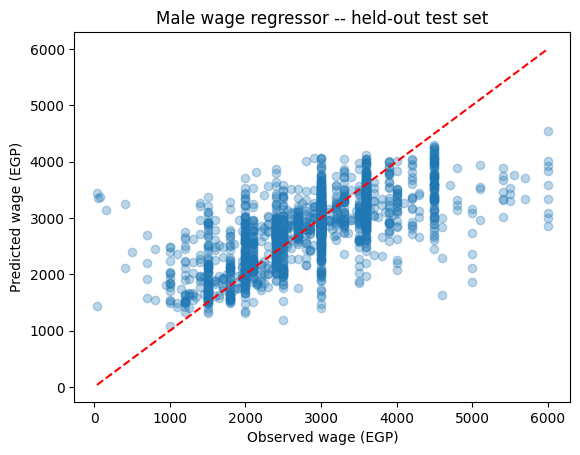

In [33]:
import matplotlib.pyplot as plt

plt.scatter(y_male_test, y_male_pred, alpha=0.3)
plt.plot([y_male_test.min(), y_male_test.max()], [y_male_test.min(), y_male_test.max()], "r--")
plt.xlabel("Observed wage (EGP)")
plt.ylabel("Predicted wage (EGP)")
plt.title("Male wage regressor -- held-out test set")
plt.show()

MALE WAGE REGRESSOR -- full results summary
Best hyperparameters: depth=8, learning_rate=0.1, l2_leaf_reg=3
Cross-validation R2 (during tuning): 0.4517

Sample sizes: n_train=7238 (80.0%), n_test=1810 (20.0%), n_total=9048

Metrics (raw wage, EGP):
  Train R2  = 0.6670
  Test R2   = 0.4503
  Test MAE  = 471.4 EGP
  Test RMSE = 673.0 EGP
  Mean-baseline test R2 (predicting the average wage for everyone) = -0.0017


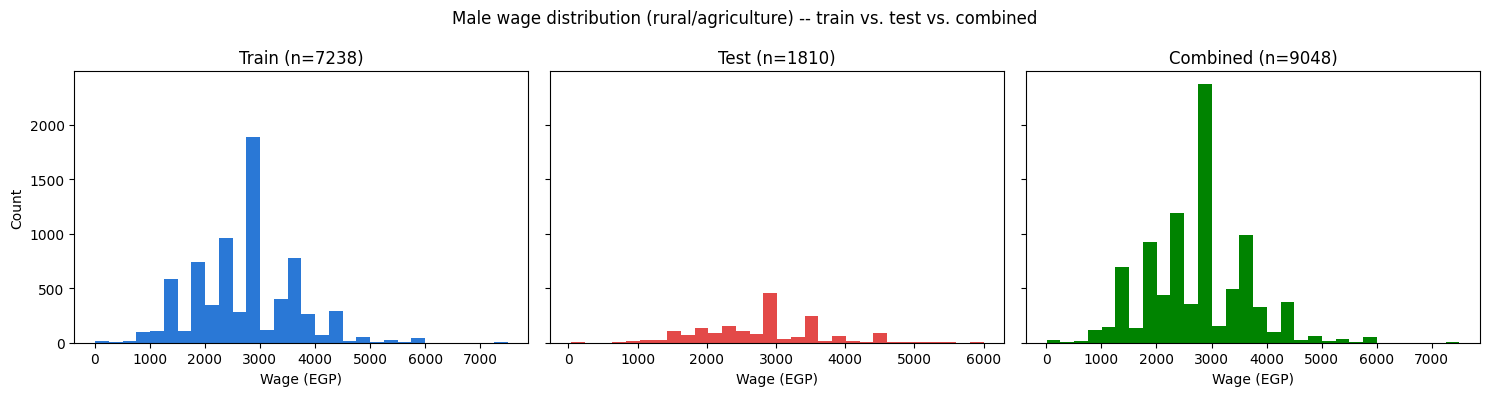

In [34]:
# ============================================================
# Male model -- full results summary: best hyperparameters, all metrics, sample sizes,
# and train/test/combined wage distributions
# ============================================================
print("MALE WAGE REGRESSOR -- full results summary")
print("=" * 60)
print(
    f"Best hyperparameters: depth={male_summary['best_depth']}, "
    f"learning_rate={male_summary['best_learning_rate']}, "
    f"l2_leaf_reg={male_summary['best_l2_leaf_reg']}"
)
print(f"Cross-validation R2 (during tuning): {male_summary['cv_best_r2']:.4f}")
print()
n_total = male_summary['n_train'] + male_summary['n_test']
print(
    f"Sample sizes: n_train={male_summary['n_train']} "
    f"({male_summary['n_train'] / n_total:.1%}), "
    f"n_test={male_summary['n_test']} ({male_summary['n_test'] / n_total:.1%}), "
    f"n_total={n_total}"
)
print()
print("Metrics (raw wage, EGP):")
print(f"  Train R2  = {male_summary['train_r2']:.4f}")
print(f"  Test R2   = {male_summary['test_r2']:.4f}")
print(f"  Test MAE  = {male_summary['test_mae']:.1f} EGP")
print(f"  Test RMSE = {male_summary['test_rmse']:.1f} EGP")
print(f"  Mean-baseline test R2 (predicting the average wage for everyone) = {male_summary['baseline_test_r2']:.4f}")

# Train vs. test vs. combined wage distribution -- checks the test set wasn't accidentally drawn
# from a different part of the wage distribution than train, and shows where most of the
# male rural/agriculture wage-earning population actually sits.
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
axes[0].hist(y_male_train, bins=30, color="#2a78d6")
axes[0].set_title(f"Train (n={len(y_male_train)})")
axes[1].hist(y_male_test, bins=30, color="#e34948")
axes[1].set_title(f"Test (n={len(y_male_test)})")
axes[2].hist(pd.concat([y_male_train, y_male_test]), bins=30, color="#008300")
axes[2].set_title(f"Combined (n={n_total})")
for ax in axes:
    ax.set_xlabel("Wage (EGP)")
axes[0].set_ylabel("Count")
fig.suptitle("Male wage distribution (rural/agriculture) -- train vs. test vs. combined")
plt.tight_layout()
plt.show()

<div style="font-size: 0.85em;">

**Female model: predict wage level** (raw wage in EGP, conditional on earning something)

Same structure as the male model on purpose: both predict wage level, not one classifier and one regressor, so a SHAP comparison between them is apples to apples. Matches the paper's own framing (Figure X compares SHAP-ranked predictors for men and women). Only respondents with totwag>0 are used, same as the male model.

</div>

In [35]:
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
# root_mean_squared_error needs sklearn>=1.4 -- use mean_squared_error ** 0.5 instead,
# which works on every sklearn version (confirmed: this environment has 1.3.0).
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
def root_mean_squared_error(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5
from catboost import CatBoostRegressor

# sex == '2' is Female (verified against survey_df).
final_sample_female = final_sample[final_sample['sex'] == '2']
final_sample_female = final_sample_female[final_sample_female['totwag'] > 0]
final_sample_female = final_sample_female[final_sample_female['totwag'] < 10000]  # same outlier cap as _ori

X_female = final_sample_female[cols].drop(columns=['hrswksc', 'totwag', 'corrected_yield_pp'])
y_female = final_sample_female['totwag']  # RAW wage, not log -- capped at <10000 above
female_cat_features = [c for c in categorical_columns if c in X_female.columns]

X_female_train, X_female_test, y_female_train, y_female_test = train_test_split(
    X_female, y_female, test_size=0.2, random_state=42,
)

female_param_grid = {"depth": [4, 6, 8], "learning_rate": [0.03, 0.1], "l2_leaf_reg": [3, 10, 30]}
female_cv = KFold(n_splits=3, shuffle=True, random_state=42)

female_search = GridSearchCV(
    estimator=CatBoostRegressor(
        iterations=300, loss_function="RMSE", random_seed=42, verbose=False,
    ),
    param_grid=female_param_grid,
    scoring="r2",
    cv=female_cv,
    refit=True,
    verbose=2,  # prints per-fold/candidate progress -- otherwise a multi-minute search looks hung
)
female_search.fit(X_female_train, y_female_train, cat_features=female_cat_features)

# Same early-stopped refit as the male model. Caveat worth flagging: with only ~325 female
# training rows, a 15% validation carve-out leaves a small (~50-row) validation set, so the
# early-stopping point itself carries more noise here than for the male model.
X_female_fit, X_female_val, y_female_fit, y_female_val = train_test_split(
    X_female_train, y_female_train, test_size=0.15, random_state=42,
)
female_model = CatBoostRegressor(
    iterations=5000, loss_function="RMSE", random_seed=42, verbose=False, **female_search.best_params_,
)
female_model.fit(
    X_female_fit, y_female_fit, eval_set=(X_female_val, y_female_val), cat_features=female_cat_features,
    use_best_model=True, early_stopping_rounds=200,
)
y_female_pred = female_model.predict(X_female_test)
print(f"  final refit used {female_model.get_best_iteration()} iterations (of a 5000 ceiling, early-stopped)")

female_grid_rows = [
    {
        "model": "female_wage_regressor",
        "depth": p["depth"],
        "learning_rate": p["learning_rate"],
        "l2_leaf_reg": p["l2_leaf_reg"],
        "cv_mean_r2": mean_s,
        "cv_std_r2": std_s,
        "is_best": p == female_search.best_params_,
    }
    for p, mean_s, std_s in zip(
        female_search.cv_results_["params"],
        female_search.cv_results_["mean_test_score"],
        female_search.cv_results_["std_test_score"],
    )
]

female_baseline_pred = np.repeat(y_female_train.mean(), len(y_female_test))

female_summary = {
    "model": "female_wage_regressor",
    "best_depth": female_search.best_params_["depth"],
    "best_learning_rate": female_search.best_params_["learning_rate"],
    "best_l2_leaf_reg": female_search.best_params_["l2_leaf_reg"],
    "cv_best_r2": female_search.best_score_,
    "test_r2": r2_score(y_female_test, y_female_pred),
    "test_mae": mean_absolute_error(y_female_test, y_female_pred),
    "test_rmse": root_mean_squared_error(y_female_test, y_female_pred),
    "train_r2": r2_score(y_female_train, female_model.predict(X_female_train)),
    "baseline_test_r2": r2_score(y_female_test, female_baseline_pred),
    "baseline_test_rmse": root_mean_squared_error(y_female_test, female_baseline_pred),
    "n_train": len(X_female_train),
    "n_test": len(X_female_test),
}
print(
    f"Female regressor -- best depth={female_summary['best_depth']}, "
    f"lr={female_summary['best_learning_rate']}, l2={female_summary['best_l2_leaf_reg']}"
)
print(
    f"  test R2={female_summary['test_r2']:.4f} (mean-baseline {female_summary['baseline_test_r2']:.4f}), "
    f"train R2={female_summary['train_r2']:.4f}"
)
print(
    f"  NOTE: only {len(X_female)} women report totwag>0 (much smaller than the male sample) "
    f"-- expect wider uncertainty in this model."
)

Fitting 3 folds for each of 18 candidates, totalling 54 fits
[CV] END .........depth=4, l2_leaf_reg=3, learning_rate=0.03; total time=  11.6s
[CV] END .........depth=4, l2_leaf_reg=3, learning_rate=0.03; total time=   9.8s
[CV] END .........depth=4, l2_leaf_reg=3, learning_rate=0.03; total time=  10.7s
[CV] END ..........depth=4, l2_leaf_reg=3, learning_rate=0.1; total time=   9.9s
[CV] END ..........depth=4, l2_leaf_reg=3, learning_rate=0.1; total time=  11.8s
[CV] END ..........depth=4, l2_leaf_reg=3, learning_rate=0.1; total time=   9.4s
[CV] END ........depth=4, l2_leaf_reg=10, learning_rate=0.03; total time=  10.4s
[CV] END ........depth=4, l2_leaf_reg=10, learning_rate=0.03; total time=   9.4s
[CV] END ........depth=4, l2_leaf_reg=10, learning_rate=0.03; total time=   9.8s
[CV] END .........depth=4, l2_leaf_reg=10, learning_rate=0.1; total time=   9.9s
[CV] END .........depth=4, l2_leaf_reg=10, learning_rate=0.1; total time=  10.0s
[CV] END .........depth=4, l2_leaf_reg=10, learn

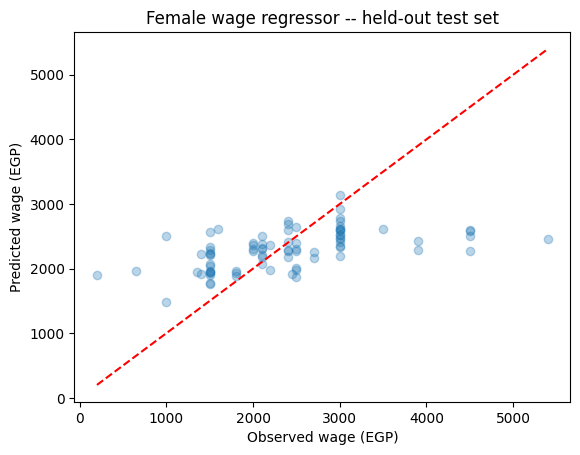

In [36]:
import matplotlib.pyplot as plt

plt.scatter(y_female_test, y_female_pred, alpha=0.3)
plt.plot([y_female_test.min(), y_female_test.max()], [y_female_test.min(), y_female_test.max()], "r--")
plt.xlabel("Observed wage (EGP)")
plt.ylabel("Predicted wage (EGP)")
plt.title("Female wage regressor -- held-out test set")
plt.show()

FEMALE WAGE REGRESSOR -- full results summary
Best hyperparameters: depth=4, learning_rate=0.1, l2_leaf_reg=10
Cross-validation R2 (during tuning): 0.1737

Sample sizes: n_train=324 (80.0%), n_test=81 (20.0%), n_total=405

Metrics (raw wage, EGP):
  Train R2  = 0.4024
  Test R2   = 0.2359
  Test MAE  = 587.9 EGP
  Test RMSE = 805.4 EGP
  Mean-baseline test R2 (predicting the average wage for everyone) = -0.0076


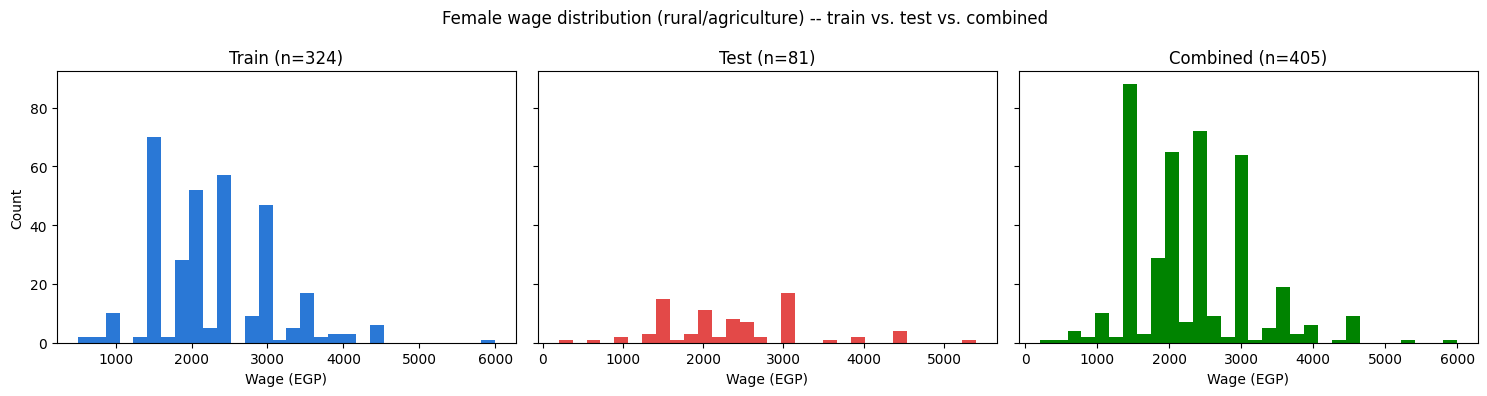

In [37]:
# ============================================================
# Female model -- full results summary: best hyperparameters, all metrics, sample sizes,
# and train/test/combined wage distributions
# ============================================================
print("FEMALE WAGE REGRESSOR -- full results summary")
print("=" * 60)
print(
    f"Best hyperparameters: depth={female_summary['best_depth']}, "
    f"learning_rate={female_summary['best_learning_rate']}, "
    f"l2_leaf_reg={female_summary['best_l2_leaf_reg']}"
)
print(f"Cross-validation R2 (during tuning): {female_summary['cv_best_r2']:.4f}")
print()
n_total = female_summary['n_train'] + female_summary['n_test']
print(
    f"Sample sizes: n_train={female_summary['n_train']} "
    f"({female_summary['n_train'] / n_total:.1%}), "
    f"n_test={female_summary['n_test']} ({female_summary['n_test'] / n_total:.1%}), "
    f"n_total={n_total}"
)
print()
print("Metrics (raw wage, EGP):")
print(f"  Train R2  = {female_summary['train_r2']:.4f}")
print(f"  Test R2   = {female_summary['test_r2']:.4f}")
print(f"  Test MAE  = {female_summary['test_mae']:.1f} EGP")
print(f"  Test RMSE = {female_summary['test_rmse']:.1f} EGP")
print(f"  Mean-baseline test R2 (predicting the average wage for everyone) = {female_summary['baseline_test_r2']:.4f}")

# Train vs. test vs. combined wage distribution -- checks the test set wasn't accidentally drawn
# from a different part of the wage distribution than train, and shows where most of the
# female rural/agriculture wage-earning population actually sits.
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
axes[0].hist(y_female_train, bins=30, color="#2a78d6")
axes[0].set_title(f"Train (n={len(y_female_train)})")
axes[1].hist(y_female_test, bins=30, color="#e34948")
axes[1].set_title(f"Test (n={len(y_female_test)})")
axes[2].hist(pd.concat([y_female_train, y_female_test]), bins=30, color="#008300")
axes[2].set_title(f"Combined (n={n_total})")
for ax in axes:
    ax.set_xlabel("Wage (EGP)")
axes[0].set_ylabel("Count")
fig.suptitle("Female wage distribution (rural/agriculture) -- train vs. test vs. combined")
plt.tight_layout()
plt.show()

In [38]:
male_imp = pd.Series(male_model.feature_importances_, index=X_male_train.columns).sort_values(ascending=False)
female_imp = pd.Series(female_model.feature_importances_, index=X_female_train.columns).sort_values(ascending=False)

print("Top 15 male wage regressor feature importances:")
print(male_imp.head(15))
print()
print("Top 15 female wage regressor feature importances:")
print(female_imp.head(15))

Top 15 male wage regressor feature importances:
emps                              12.438476
hrswk                             12.315029
female_child_married               8.795807
tenure                             7.002912
female_violence_sexual             5.938177
empstab                            4.624848
age                                4.418120
female_contraceptives_decision     3.515827
yeduc                              3.192700
female_unemployment_rate           3.157651
household_size                     2.421887
female_healthcare_decision         1.889316
command_unit                       1.531483
female_violence_physical           1.441543
p_poor_population                  1.402000
dtype: float64

Top 15 female wage regressor feature importances:
tenure                         8.995393
hrswk                          7.849181
corrected_yield_Cabbages       7.116973
empstab                        4.905573
female_healthcare_decision     4.760630
emps                      

Male wage regressor -- SHAP summary (rural/agriculture):


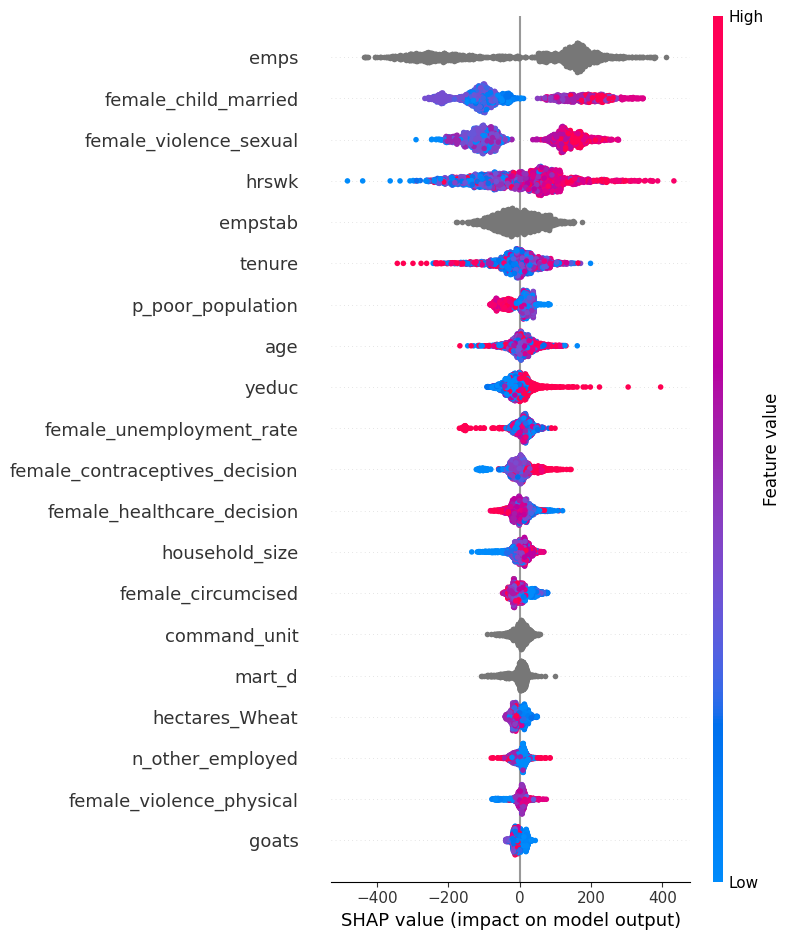

Female wage regressor -- SHAP summary (rural/agriculture):


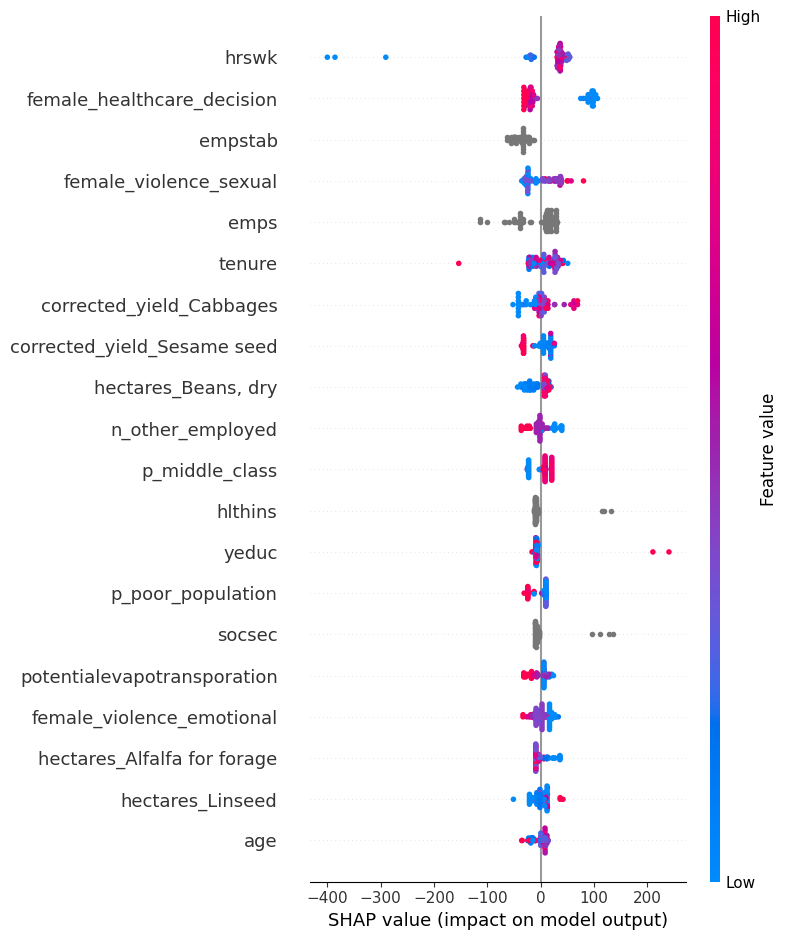

In [39]:
# SHAP comparison for both genders -- the paper's actual stated deliverable (Figure X:
# "Comparison of SHAP values for men and women across the 10 highest SHAP-ranked predictors").
# Not present in this notebook before -- added here to match the full-survey version.
import shap

male_explainer = shap.TreeExplainer(male_model)
male_shap_values = male_explainer.shap_values(X_male_test)

female_explainer = shap.TreeExplainer(female_model)
female_shap_values = female_explainer.shap_values(X_female_test)

print("Male wage regressor -- SHAP summary (rural/agriculture):")
shap.summary_plot(male_shap_values, X_male_test, show=True)

print("Female wage regressor -- SHAP summary (rural/agriculture):")
shap.summary_plot(female_shap_values, X_female_test, show=True)

In [40]:
# Save every hyperparameter combination tried (not just the winner) plus the final summary
# metrics for both models -- fully reproducible: every random seed is fixed (command-unit
# assignment rng=42, both train_test_splits random_state=42, both GridSearchCV KFold
# random_state=42, both CatBoost random_seed=42).
male_grid_df = pd.DataFrame(male_grid_rows)
female_grid_df = pd.DataFrame(female_grid_rows)
model_summary_df = pd.DataFrame([male_summary, female_summary])

male_grid_df.to_csv(RESULT_DIR / "male_regressor_grid_search_RAW10k.csv", index=False)
female_grid_df.to_csv(RESULT_DIR / "female_regressor_grid_search_RAW10k.csv", index=False)
model_summary_df.to_csv(RESULT_DIR / "model_summary_metrics_RAW10k.csv", index=False)

print(f"Saved grid-search + summary metrics to {RESULT_DIR}")
model_summary_df

Saved grid-search + summary metrics to d:\KARISMA\POST GRADUATE\UT\Intership\Deltares\GITHUB\egypt-survey-ml\ERF_Data\Data\04_Data\Result


,model,best_depth,best_learning_rate,best_l2_leaf_reg,cv_best_r2,test_r2,test_mae,test_rmse,train_r2,baseline_test_r2,baseline_test_rmse,n_train,n_test
0,male_wage_regressor,8,0.1,3,0.451736,0.450306,471.447660,673.025821,0.667033,-0.001678,908.521963,7238,1810
1,female_wage_regressor,4,0.1,10,0.173665,0.235941,587.885712,805.358236,0.402428,-0.007600,924.846803,324,81
